# Agriculture Yield Analysis
### Exploratory Data Analysis Of Crop Yield 

### Introduction
- This project analyzes agriculture crop yield 
data to understand how different environmental
and farming factors affect crop production.

- The analysis focuses on rainfall,temperature, 
soil type,crop type,fertilizer use,irrigation,
weather conditions,and days to harvest.





### Business Problem
- Farmers need to understand which environmental 
and farming factors are associated with higher
crop yield.

- This analysis aims to identify patterns in crop
yield and understand how rainfall,
temperature,soil type, irrigation, fertilizer use,
weather conditions, crop type, and days to harvest are associated with crop yield.

### Dataset Overview
- The dataset contains agricultural observations
  covering different crops, region, soil type,
  weather condition, and farming practices.

- The main target variable is crop Yield, measured in tons per hectare.
### Key Variables
- Region -- Geographic region
- Soil_Type -- Type of soil (land)
- Crop -- Crop being grown
- Rainfall_mm -- Rainfall in millimeters
- Temperature_Celsius -- Temperature in Celsius
- Fertilizer -- Whether fertilizer was used
- Irrigation -- Whether irrigation was used
- Weather_Condition -- Weather condition
- Days_to_Harvest -- Number of days until harvest
- Yield_tons_per_hectare -- Crop yield in tons per hectare 

## Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df_small = pd.read_csv('crop_yield.csv', nrows=5000)

In [3]:
df_small.columns

Index(['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius',
       'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition',
       'Days_to_Harvest', 'Yield_tons_per_hectare'],
      dtype='object')

In [4]:
df_small.rename(columns={
    'Temperature_Celsius': 'Temperature_C',
    'Fertilizer_Used' : 'Fertilizer',
    'Irrigation_Used': 'Irrigation',
    'Weather_Condition': 'Weather',
    'Yield_tons_per_hectare': 'Yield',

}, inplace=True)

In [5]:
df_small.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_C,Fertilizer,Irrigation,Weather,Days_to_Harvest,Yield
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


# Data Cleaning

In [6]:
df_small['Weather']=df_small['Weather'].str.capitalize()

In [7]:
df_small['Weather'].value_counts()

Weather
Sunny     1737
Cloudy    1653
Rainy     1610
Name: count, dtype: int64

In [8]:
df_small.duplicated().sum()

np.int64(0)

In [9]:
df_small = df_small.drop_duplicates()

In [10]:
df_small.duplicated().sum()

np.int64(0)

In [11]:
df_small.isnull().sum()

Region             0
Soil_Type          0
Crop               0
Rainfall_mm        0
Temperature_C      0
Fertilizer         0
Irrigation         0
Weather            0
Days_to_Harvest    0
Yield              0
dtype: int64

In [12]:
df_small['Crop'].value_counts()

Crop
Barley     855
Rice       851
Wheat      845
Maize      837
Cotton     814
Soybean    798
Name: count, dtype: int64

In [13]:
df_small['Crop'] = df_small['Crop'].fillna(df_small['Crop'].mode()[0])

In [14]:
df_small['Fertilizer'] = df_small['Fertilizer'].replace('Yes', True)

In [15]:
df_small['Crop'] = df_small['Crop'].str.strip().str.capitalize()

In [16]:
df_small['Weather'] = df_small['Weather'].replace('Raniy', 'Rainy')

In [17]:
df_small['Rainfall_mm'].describe()

count    5000.000000
mean      545.825249
std       256.869245
min       100.105325
25%       324.420302
50%       546.220773
75%       766.347818
max       999.639444
Name: Rainfall_mm, dtype: float64

In [18]:
df_small[df_small['Rainfall_mm'] <0]

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_C,Fertilizer,Irrigation,Weather,Days_to_Harvest,Yield


In [19]:
df_small.loc[df_small['Rainfall_mm'] < 0,'Rainfall_mm'] = None

In [20]:
df_small['Rainfall_mm'].median()

np.float64(546.2207734805606)

In [21]:
df_small['Rainfall_mm'] = df_small['Rainfall_mm'].fillna(df_small['Rainfall_mm'].median())

In [22]:
df_small['Temperature_C'].describe()

count    5000.000000
mean       27.490546
std         7.218531
min        15.000276
25%        21.206594
50%        27.638656
75%        33.735105
max        39.997860
Name: Temperature_C, dtype: float64

In [23]:
Q1 = df_small['Temperature_C'].quantile(0.25)
Q3 = df_small['Temperature_C'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_small[
    (df_small['Temperature_C'] < lower_bound) | 
    (df_small['Temperature_C'] > upper_bound)
]

print('The number of outliers', len(outliers))



The number of outliers 0


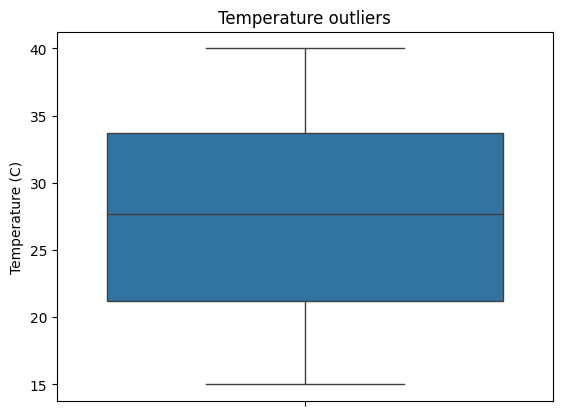

In [24]:
sns.boxplot(df_small['Temperature_C'])
plt.ylabel('Temperature (C)')
plt.title('Temperature outliers')
plt.show()

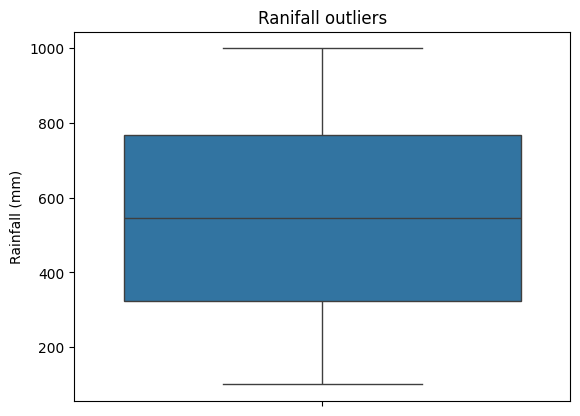

In [25]:
sns.boxplot(df_small['Rainfall_mm'])
plt.ylabel('Rainfall (mm)')
plt.title('Ranifall outliers')
plt.show()

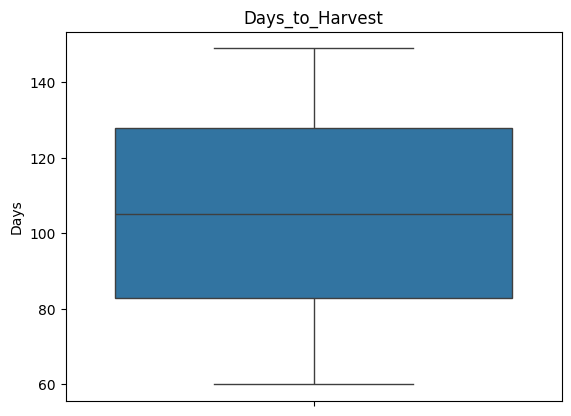

In [26]:
sns.boxplot(df_small['Days_to_Harvest'])
plt.ylabel('Days')
plt.title('Days_to_Harvest')
plt.show()

In [27]:
Q1 = df_small['Days_to_Harvest'].quantile(0.25)
Q3 = df_small['Days_to_Harvest'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('Q1:', Q1)
print('Q3:', Q3)
print('lower_bound:', lower_bound)
print('upper_bound:', upper_bound)

outliers = df_small[
    (df_small['Days_to_Harvest'] < lower_bound) |
    (df_small['Days_to_Harvest'] > upper_bound)
]

print('The numbers of outliers', len(outliers))


Q1: 83.0
Q3: 128.0
lower_bound: 15.5
upper_bound: 195.5
The numbers of outliers 0


In [28]:
outliers[['Days_to_Harvest']]

,Days_to_Harvest


In [29]:
df_small.loc[df_small['Days_to_Harvest'] < 0, 'Days_to_Harvest'] = np.nan

In [30]:
df_small['Days_to_Harvest'].median()

np.float64(105.0)

In [31]:
df_small['Days_to_Harvest'] = df_small['Days_to_Harvest'].fillna(df_small['Days_to_Harvest'].median())

In [32]:
df_small.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Region           5000 non-null   object 
 1   Soil_Type        5000 non-null   object 
 2   Crop             5000 non-null   object 
 3   Rainfall_mm      5000 non-null   float64
 4   Temperature_C    5000 non-null   float64
 5   Fertilizer       5000 non-null   bool   
 6   Irrigation       5000 non-null   bool   
 7   Weather          5000 non-null   object 
 8   Days_to_Harvest  5000 non-null   float64
 9   Yield            5000 non-null   float64
dtypes: bool(2), float64(4), object(4)
memory usage: 322.4+ KB


In [33]:
df_small['Days_to_Harvest'] = df_small['Days_to_Harvest'].astype(int)

In [34]:
df_small.shape

(5000, 10)

In [35]:
df_small.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_C,Fertilizer,Irrigation,Weather,Days_to_Harvest,Yield
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


## Exploratory Data Analysis
### After Cleaning the dataset, exploratory data analysis was performed to understand the patterns and relationships between crop yield and different agricultural factors

### 1. Yield Distribution

- The distribution of crop yield shows how frequently different yield levels occur in the dataset

In [36]:
df_small['Yield'].describe()

count    5000.000000
mean        4.647330
std         1.707913
min        -0.007103
25%         3.391037
50%         4.677672
75%         5.885910
max         9.196672
Name: Yield, dtype: float64

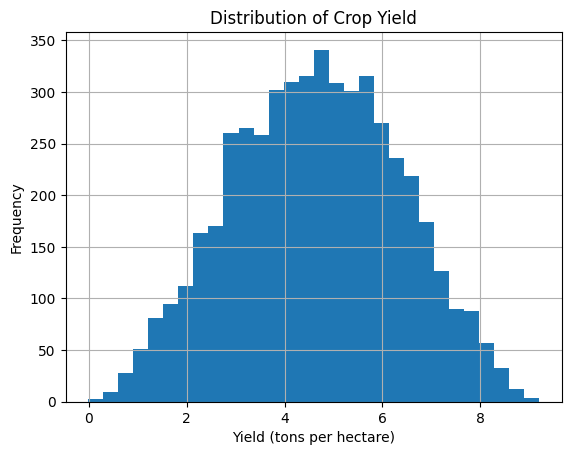

In [37]:
plt.Figure(figsize=(8, 5))

df_small['Yield'].hist(bins=30)

plt.title('Distribution of Crop Yield')
plt.xlabel('Yield (tons per hectare)')
plt.ylabel('Frequency')
plt.show()

In [38]:
df_small['Yield'].skew()

np.float64(-0.023480112361523482)

In [39]:
df_small['Yield'].kurt()

np.float64(-0.5578019631212157)

In [40]:
df_small['Yield'].mean()

np.float64(4.647329874817933)

In [41]:
df_small['Yield'].median()

np.float64(4.677672017793441)

In [42]:
df_small['Yield'].min()

np.float64(-0.0071032690598451)

In [43]:
df_small['Yield'].max()

np.float64(9.196672119024027)

### Outlier Analysis

In [44]:
df_small['Yield'].nsmallest(5)

756    -0.007103
406     0.214407
4545    0.234537
1359    0.333370
3352    0.365200
Name: Yield, dtype: float64

In [45]:
df_small['Yield'].describe()

count    5000.000000
mean        4.647330
std         1.707913
min        -0.007103
25%         3.391037
50%         4.677672
75%         5.885910
max         9.196672
Name: Yield, dtype: float64

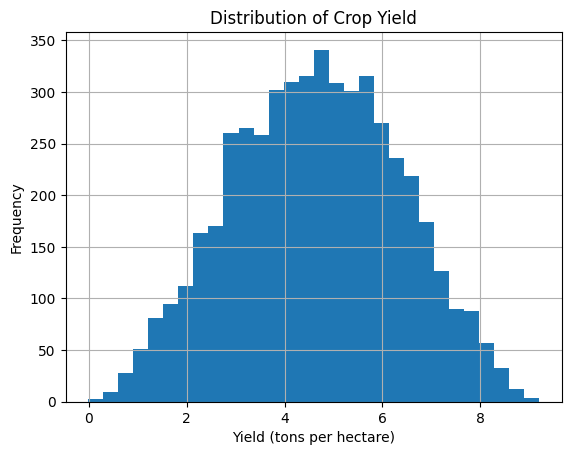

In [46]:
plt.Figure(figsize=(8, 5))

df_small['Yield'].hist(bins=30)
plt.title('Distribution of Crop Yield')
plt.xlabel('Yield (tons per hectare)')
plt.ylabel('Frequency')
plt.show()

In [47]:
Q1 = df_small['Yield'].quantile(0.25)
Q3 = df_small['Yield'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_small[
    (df_small['Yield'] < lower_bound)|
    (df_small['Yield'] > upper_bound)
]

print('lower_bound', lower_bound)
print('upper_bound', upper_bound)
print('Numbers of outliers', len(outliers))

lower_bound -0.35127154561126783
upper_bound 9.628218574391646
Numbers of outliers 0


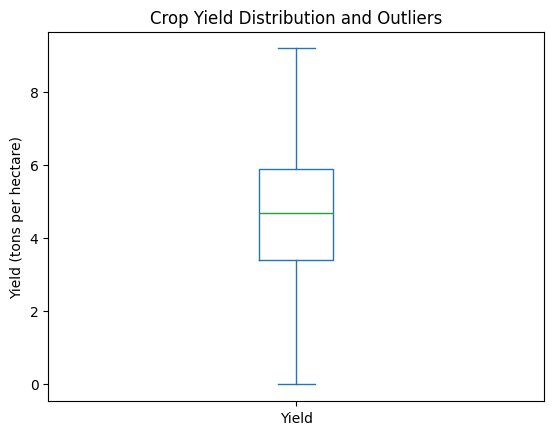

In [48]:
plt.Figure(figsize=(8, 5))

df_small['Yield'].plot(kind='box')
plt.title('Crop Yield Distribution and Outliers')
plt.ylabel('Yield (tons per hectare)')
plt.show()

## Numerical Feature Analysis 
#### Numerical features were analyzed to understand their relationship with crop yield and identify which environmental factors have the strongest association with agricultural production.

### Rainfall vs Crop Yield
- Rainfall analyzed to understand its relationship with crop yield and identify whether higher rainfall is associated with higher agricultural production.

<Figure size 800x500 with 0 Axes>

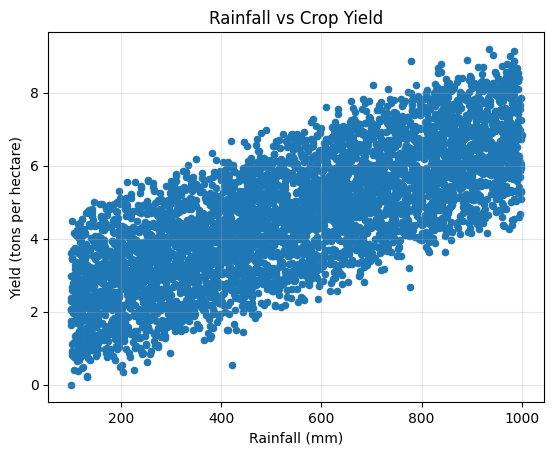

In [49]:
plt.figure(figsize=(8, 5))

df_small.plot(x='Rainfall_mm', y='Yield', kind='scatter')
plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (tons per hectare)')
plt.grid(alpha=0.3)
plt.show()

In [50]:
df_small['Rainfall_mm'].corr(df_small['Yield'])

np.float64(0.7593444811476988)

In [51]:

df_small.groupby('Crop')[['Rainfall_mm', 'Yield']].corr()

Rainfall_mm     Yield
Crop                                      
Barley  Rainfall_mm     1.000000  0.755290
        Yield           0.755290  1.000000
Cotton  Rainfall_mm     1.000000  0.759592
        Yield           0.759592  1.000000
Maize   Rainfall_mm     1.000000  0.772378
        Yield           0.772378  1.000000
Rice    Rainfall_mm     1.000000  0.754464
        Yield           0.754464  1.000000
Soybean Rainfall_mm     1.000000  0.767026
        Yield           0.767026  1.000000
Wheat   Rainfall_mm     1.000000  0.746759
        Yield           0.746759  1.000000

### 2. Temperature vs Crop Yield

- Temperature was analyzed to understand its relationship with crop yield and determine whether temperature has a noticeable impact on agricultural production.

<Figure size 800x500 with 0 Axes>

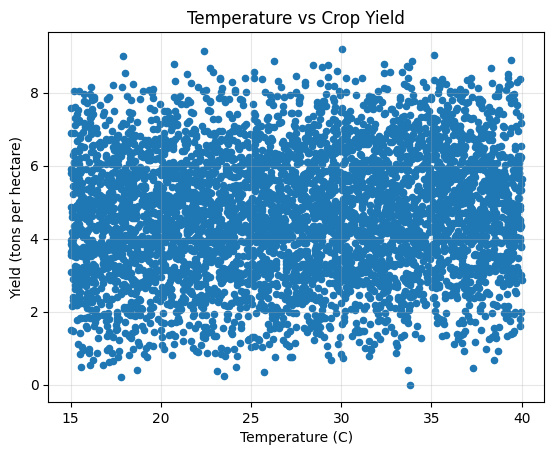

In [52]:
plt.figure(figsize=(8, 5))

df_small.plot(x='Temperature_C', y='Yield', kind='scatter')
plt.title('Temperature vs Crop Yield')
plt.xlabel('Temperature (C)')
plt.ylabel('Yield (tons per hectare)')
plt.grid(alpha=0.3)
plt.show()

In [53]:
df_small['Temperature_C'].corr(df_small['Yield'])

np.float64(0.09531839804625851)

In [54]:
df_small.groupby('Crop')[['Temperature_C', 'Yield']].corr()

Temperature_C     Yield
Crop                                          
Barley  Temperature_C       1.000000  0.065138
        Yield               0.065138  1.000000
Cotton  Temperature_C       1.000000  0.117496
        Yield               0.117496  1.000000
Maize   Temperature_C       1.000000  0.101512
        Yield               0.101512  1.000000
Rice    Temperature_C       1.000000  0.081991
        Yield               0.081991  1.000000
Soybean Temperature_C       1.000000  0.079374
        Yield               0.079374  1.000000
Wheat   Temperature_C       1.000000  0.125410
        Yield               0.125410  1.000000

### 3. Days to Harvest vs Crop Yield

- Days to harvest was analyzed to understand whether the harvesting period has any noticeable relationship with crop yield. 

<Figure size 800x500 with 0 Axes>

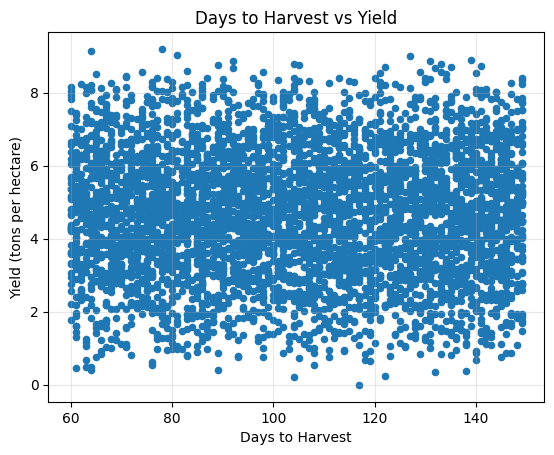

In [55]:
plt.figure(figsize=(8, 5))

df_small.plot(x='Days_to_Harvest', y='Yield', kind='scatter')
plt.title('Days to Harvest vs Yield')
plt.xlabel('Days to Harvest')
plt.ylabel('Yield (tons per hectare)')
plt.grid(alpha=0.3)
plt.show()

In [56]:
df_small['Days_to_Harvest'].corr(df_small['Yield'])

np.float64(-0.017250602161267708)

In [57]:
df_small.groupby('Crop')['Days_to_Harvest'].corr(df_small['Yield'])

Crop
Barley    -0.014872
Cotton    -0.023194
Maize     -0.045848
Rice       0.038021
Soybean    0.020068
Wheat     -0.079237
Name: Days_to_Harvest, dtype: float64

## Categorical Feature Analysis 
- Categorical features were analyzed to understand how different farming and environmental categories are associated with crop yield.

### 1. Crop vs Crop Yield
- Crop-wise yield was analyzed to compare the yield distribution across different crops and identify which crops show higher or lower production.

In [58]:
df_small.groupby('Crop')['Yield'].mean().sort_values(ascending=False)

Crop
Rice       4.728701
Wheat      4.665430
Soybean    4.640853
Cotton     4.633139
Barley     4.623774
Maize      4.590362
Name: Yield, dtype: float64

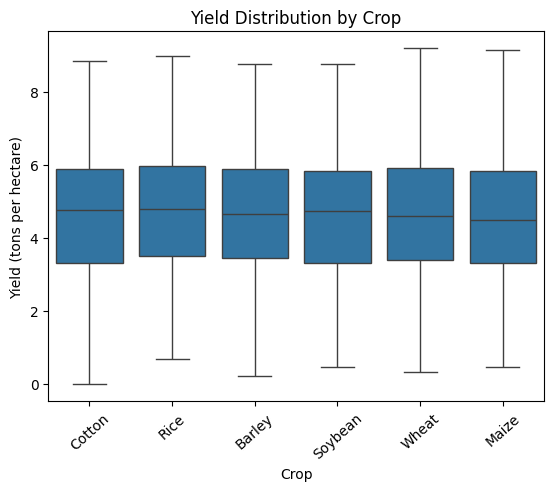

In [59]:
plt.Figure(figsize=(8, 5))

sns.boxplot(data=df_small, x='Crop', y='Yield')
plt.title('Yield Distribution by Crop')
plt.xlabel('Crop')
plt.ylabel('Yield (tons per hectare)')
plt.xticks(rotation=42)
plt.show()


In [60]:
df_small.groupby('Crop')['Yield'].describe()

,count,mean,std,min,25%,50%,75%,max
Crop,,,,,,,,
Barley,855.0,4.623774,1.661067,0.214407,3.459591,4.642738,5.879884,8.772365
Cotton,814.0,4.633139,1.757574,-0.007103,3.309112,4.762602,5.879329,8.852316
Maize,837.0,4.590362,1.724009,0.470258,3.311667,4.485515,5.828001,9.136935
Rice,851.0,4.728701,1.711654,0.687913,3.517056,4.791057,5.973811,8.995940
Soybean,798.0,4.640853,1.719240,0.461158,3.315462,4.731857,5.841773,8.772387
Wheat,845.0,4.665430,1.677164,0.333370,3.407579,4.593409,5.910784,9.196672


In [61]:
df_small['Crop'].value_counts()

Crop
Barley     855
Rice       851
Wheat      845
Maize      837
Cotton     814
Soybean    798
Name: count, dtype: int64

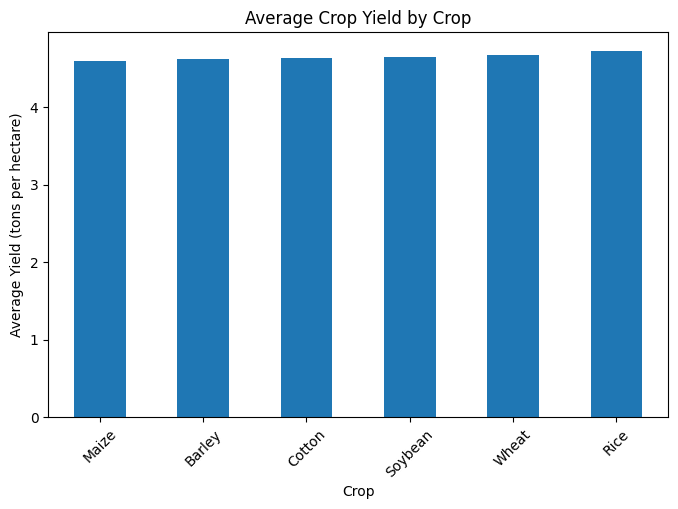

In [62]:
df_small.groupby('Crop')['Yield'].mean().sort_values().plot(kind='bar', figsize=(8, 5))
plt.title('Average Crop Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Yield (tons per hectare)')
plt.xticks(rotation=45)
plt.show()

### 2. Fertilizer Use vs Crop
- Fertilizer use was analyzed to understand whether the use of fertilizer is associated with higher crop yield. 

In [63]:
df_small.groupby('Fertilizer')['Yield'].mean().sort_values(ascending=False)

Fertilizer
True     5.408551
False    3.858203
Name: Yield, dtype: float64

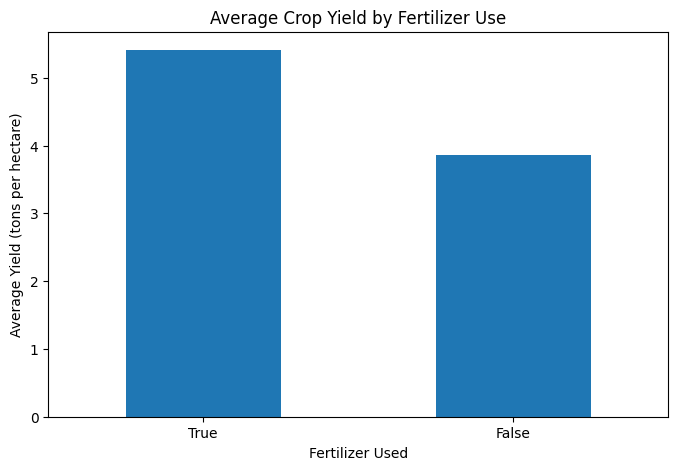

In [64]:
df_small.groupby('Fertilizer')['Yield'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(8, 5))

plt.title('Average Crop Yield by Fertilizer Use')
plt.xlabel('Fertilizer Used')
plt.ylabel('Average Yield (tons per hectare)')
plt.xticks(rotation=0)
plt.show()

### 3. Irrigation Use vs Crop Yield

- Irrigation use was analyzed to understand whether irrigation is associated with higher crop yield and improved agricultural production.


In [65]:
df_small.groupby('Irrigation')['Yield'].mean().sort_values(ascending=False)

Irrigation
True     5.290544
False    4.007196
Name: Yield, dtype: float64

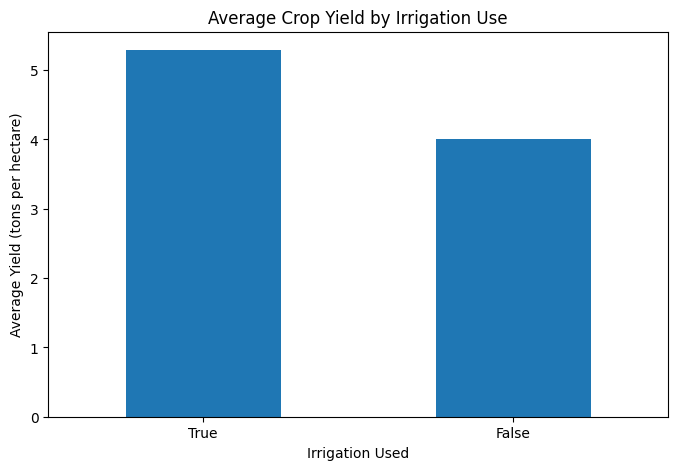

In [66]:
df_small.groupby('Irrigation')['Yield'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(8, 5))

plt.title('Average Crop Yield by Irrigation Use')
plt.xlabel('Irrigation Used')
plt.ylabel('Average Yield (tons per hectare)')
plt.xticks(rotation=0)
plt.show()

### 4. Region vs Crop Yield

- Regional differences were analyzed to understand whether crop yield varies across different region

In [67]:
df_small.groupby('Region')['Yield'].mean().sort_values(ascending=False)

Region
East     4.706378
South    4.693274
North    4.601163
West     4.595462
Name: Yield, dtype: float64

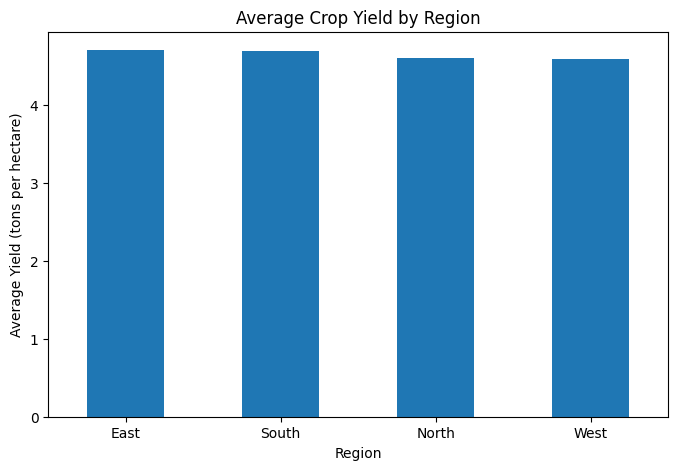

In [68]:
df_small.groupby('Region')['Yield'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(8, 5))

plt.title('Average Crop Yield by Region')
plt.xlabel('Region')
plt.ylabel('Average Yield (tons per hectare)')
plt.xticks(rotation=0)
plt.show()

## 5. Soil Type vs Crop Yield

- Soil type was analyzed to understand how different soil conditions are associated with crop yield and agricultural production.

In [69]:
df_small.groupby('Soil_Type')['Yield'].mean().sort_values(ascending=False)

Soil_Type
Clay      4.715756
Silt      4.688896
Peaty     4.668315
Chalky    4.629989
Sandy     4.593061
Loam      4.590156
Name: Yield, dtype: float64

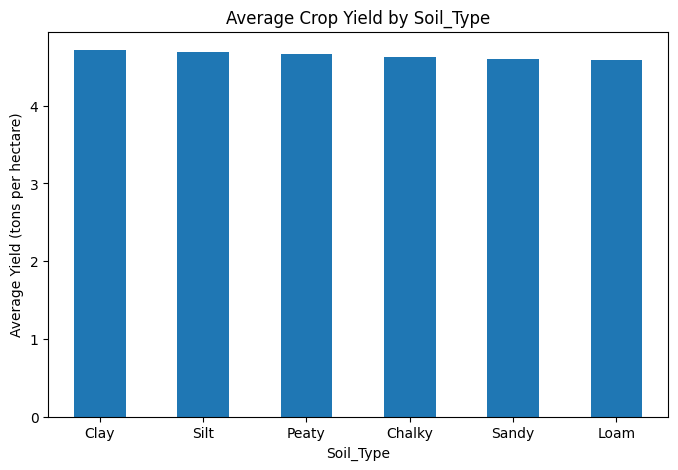

In [70]:
df_small.groupby('Soil_Type')['Yield'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(8, 5))

plt.title('Average Crop Yield by Soil_Type')
plt.xlabel('Soil_Type')
plt.ylabel('Average Yield (tons per hectare)')
plt.xticks(rotation=0)
plt.show()

### 6. Weather Conditions vs Crop Yield

- Weather conditions were analyzed to compare crop yield under different weather conditions.

In [71]:
df_small.groupby('Weather')['Yield'].mean().sort_values(ascending=False)

Weather
Cloudy    4.681734
Sunny     4.656026
Rainy     4.602626
Name: Yield, dtype: float64

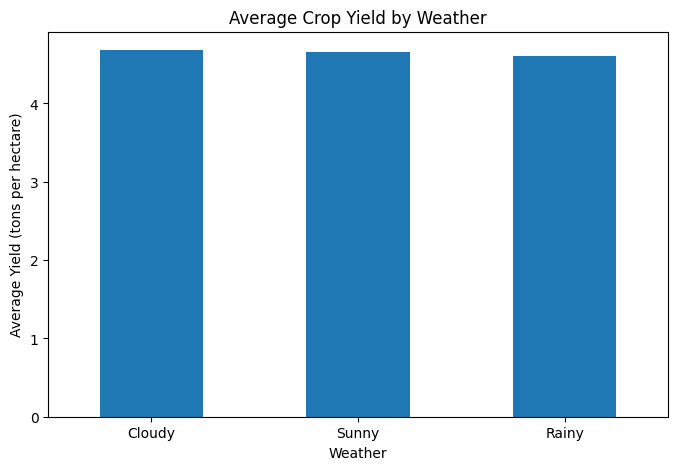

In [72]:
df_small.groupby('Weather')['Yield'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(8, 5))

plt.title('Average Crop Yield by Weather')
plt.xlabel('Weather')
plt.ylabel('Average Yield (tons per hectare)')
plt.xticks(rotation=0)
plt.show()

## Key Insights / Findings
- Rainfall showed the strongest relationship with crop yield, with a correlation of approximately 0.76.
- Temperature showed a weak positive relationship with crop yield, with a correlation of approximately 0.09.
- Days to harvest showed almost no relationship with crop yield, with a correlation of approximately -0.01
- Rice showed the highest average crop yield among the analyzed crops.
- Fertilizer use was associated with higher average crop yield, compared with no fertilizer use.
- Irrigation use was associated with higher average crop yield, compared with no irrigation use.
- Soil type and region showed differences in average crop yield, but their effects were less pronounced than rainfall, fertilizer, and irrigation.
- Weather conditions showed relatively small differences in average crop yield.
- The yield distribution contained no significant IQR-based outliers after data cleaning    

## Business Recommendations
- Prioritize crops and farming practices that show stronger yield performance in the analyzed data.
- Maintain effective irrigation practices where water availability allows, as irrigation was associated with higher average yield.
- Use fertilizer based on soil and crop requirements to support better productivity while avoiding unnecessary application.
- Monitor rainfall patterns closely because rainfall showed the strongest relationship with crop yield.
- Consider local soil conditions when selecting crops and planning farming practices.
- Avoid making decisions based on a single factor; combine rainfall, irrigation, fertilizer, crop type, soil type, and regional conditions.
- For further farming decisions, collect local field-level data to build more accurate recommendations for specific land and climate conditions.

## Conclusion
- The exploratory data analysis identified important relationships between agricultural factors and crop yield. Rainfall showed the strongest relationship with yield, while fertilizer use and irrigation were associated with higher average production. Crop, soil type, region, and weather conditions also showed differences in yield performance.
- Overall, the analysis demonstrates how data can be used to understand agricultural patterns and support more informed farming decisions. Further analysis using local field-level data and machine learning models could provide more accurate crop yield predictions and actionable recommendations.    

### Future improvements for this project include:
- Collecting more detailed field-level agricultural data from different regions.
- Building a machine learning model to predict crop yield.
- Developing a crop selection recommendation system based on soil, rainfall, temperature, irrigation, and fertilizer condition.
- Adding market prices and production costs to estimate expected revenue and profit.
- Comparing crops based on both expected yield and profitability.
- Developing an interactive dashboard for farmers and agricultural decision-making.
- Expanding the dataset to include more crops, regions, and environmental conditions 

In [73]:
df_small.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_C,Fertilizer,Irrigation,Weather,Days_to_Harvest,Yield
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [74]:
df_small.shape

(5000, 10)

In [75]:
df_small.dtypes

Region              object
Soil_Type           object
Crop                object
Rainfall_mm        float64
Temperature_C      float64
Fertilizer            bool
Irrigation            bool
Weather             object
Days_to_Harvest      int64
Yield              float64
dtype: object

# Machine Learning 

In [76]:
X = df_small.drop('Yield', axis=1)
Y = df_small['Yield']

In [80]:
Y.shape

(5000,)

In [84]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_col = ['Region', 'Weather', 'Soil_Type', 'Crop']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_col)
    ],remainder='passthrough'
    
)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
model = Pipeline
]